**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 1: Hebbian Learning

#### Week 4: Decoding class labels from Competitive Hebbian Network activations

You will use single layer artificial neural networks to **decode** (i.e. predict) the class label corresponding to each MNIST and CIFAR-10 sample **encoded** (i.e. processed) by your Competitive Hebbian Network. This will take advantage of the Competitive Hebbian Network weights that you saved off last week. Once you obtain the Competitive Hebbian Network activations, you will predict the class labels and compute the classification accuracy for each dataset obtained by this **encoder-decoder** neural network architecture.

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

## Task 9: Decode class labels from Hebbian network activations

The goal of this task is to train your linear and nonlinear decoder networks to classify MNIST digits (then later on CIFAR-10 classes) based on the Hebbian activations to each sample.

In [3]:
from image_datasets import get_dataset, train_val_split
from decoder_nets import LinearDecoder, NonlinearDecoder
from hebb_net import HebbNet

### 9a. Preparing decoder inputs

In the cell below:
1. Load MNIST in train/test/validation samples. Use the default validation split.
2. Process them with your Competitive Hebbian Network (i.e. compute their corresponding netIn values) to get the input for your decoders.

**Tips:**
- Your Hebbian network constructor has a keyword argument that you can use to load wts from a previously trained network. You should **NOT** retrain your Hebbian network here!
- When creating your Hebbian network object, remember to build it with the same hyperparameters as you did last week (e.g. number of neurons, `k` value).

In [54]:
# Load MNIST dataset
x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist = get_dataset('mnist', verbose=True, norm_method='center')
# x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist = get_dataset('mnist', verbose=True)

# Split into train and validation
x_train_mnist_split, y_train_mnist_split, x_val_mnist, y_val_mnist = train_val_split(x_train_mnist, y_train_mnist)

print(f'Train: {x_train_mnist_split.shape}, Val: {x_val_mnist.shape}, Test: {x_test_mnist.shape}')

# Load the pre-trained Hebbian network (same hyperparams as Week 2: 2000 neurons, k=6, inhib_value=-0.4)
# hebb_mnist = HebbNet(784, 2000, k=6, inhib_value=-0.4, load_wts=True, saved_wts_path='export/wts.npy')
hebb_mnist = HebbNet(784, 2000, k=6, inhib_value=-0.4, load_wts=True, saved_wts_path='export/wts_centered.npy')

# Compute net_in activations for train, val, and test sets
# These serve as features for the decoder networks
x_train_hebb = tf.concat([hebb_mnist.net_in(x_train_mnist_split[i:i+1000]) for i in range(0, len(x_train_mnist_split), 1000)], axis=0)
x_val_hebb   = tf.concat([hebb_mnist.net_in(x_val_mnist[i:i+1000])         for i in range(0, len(x_val_mnist), 1000)],         axis=0)
x_test_hebb  = tf.concat([hebb_mnist.net_in(x_test_mnist[i:i+1000])        for i in range(0, len(x_test_mnist), 1000)],        axis=0)

print(f'Hebbian train feats: {x_train_hebb.shape}')
print(f'Hebbian val feats:   {x_val_hebb.shape}')
print(f'Hebbian test feats:  {x_test_hebb.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)
Loaded stored wts.
Hebbian train feats: (54000, 2000)
Hebbian val feats:   (6000, 2000)
Hebbian test feats:  (10000, 2000)


### 9b. Train linear decoder (MNIST)

Train your softmax classifier on the Hebbian network `net_in` activations obtained from processing the MNIST training set. Keep default hyperparameters except:
1. Play around with the mini-batch size. Try starting with `256` and adjust as needed.
2. Feel free to change the `patience` depending on your patience. A patience around `3-7` should produce good results.
3. Try a learning rate decay patience of `3-5` with max decays set to `3-4`. Adjust as needed.

#### Guidelines

- **DO NOT COPY AND PASTE HYPERPARAMETERS FROM THE IRIS TEST CODE CELLS!** They will not work well for MNIST 🙄
- Training should be fairly quick (no more than a few minutes).
- **Remember:** you are **NOT** training the linear classifier **on MNIST** — you are training it on the `net_in` values produced by the Competitive Hebbian Network that you trained above!

Your results should be comparable to that of the linear decoder trained on the MNIST samples directly.

In [55]:
tf.random.set_seed(0)

# Number of Hebbian neurons = 2000, number of classes = 10
H = x_train_hebb.shape[1]  # 2000
C = 10

linear_dec_mnist = LinearDecoder(input_feats_shape=(H,), C=C)
linear_dec_mnist.compile(loss='cross_entropy', lr=1e-3)

start_time = time.time()
train_loss_lin_mnist, val_loss_lin_mnist, val_acc_lin_mnist, num_epochs_lin_mnist = linear_dec_mnist.fit(
    x_train_hebb, y_train_mnist_split,
    x_val=x_val_hebb, y_val=y_val_mnist,
    batch_size=256,
    max_epochs=200,
    patience=5,
    lr_patience=3,
    lr_max_decays=4,
    lr_decay_factor=0.5,
    val_every=1,
    print_every=1,
    verbose=True
)
total_time_lin_mnist = time.time() - start_time

test_acc_lin_mnist, test_loss_lin_mnist = linear_dec_mnist.evaluate(x_test_hebb, y_test_mnist)
print(f'\nLinear Decoder MNIST Test accuracy: {test_acc_lin_mnist.numpy()*100:.2f}%')
print(f'\nLinear Decoder MNIST Validation accuracy: {max(val_acc_lin_mnist)*100:.2f}%')
print(f'Training took: {total_time_lin_mnist:.2f} secs')

---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/199, Training loss 0.602229, Val loss 0.344184, Val acc 0.8958
Epoch 0 took: 2.3 secs
Epoch 1/199, Training loss 0.415070, Val loss 0.355679, Val acc 0.8904
Epoch 1 took: 2.4 secs
Epoch 2/199, Training loss 0.386127, Val loss 0.331986, Val acc 0.9009
Epoch 2 took: 2.4 secs
Epoch 3/199, Training loss 0.374121, Val loss 0.323966, Val acc 0.9012
Epoch 3 took: 2.5 secs
Epoch 4/199, Training loss 0.376007, Val loss 0.319637, Val acc 0.9074
Epoch 4 took: 2.5 secs
Epoch 5/199, Training loss 0.365706, Val loss 0.292689, Val acc 0.9141
Epoch 5 took: 2.5 secs
Epoch 6/199, Training loss 0.372015, Val loss 0.277543, Val acc 0.9202
Epoch 6 took: 2.9 secs
Epoch 7/199, Training loss 0.366535, Val loss 0.279461, Val acc 0.9196
Epoch 7 took: 2.5 secs
Epoch 8/199, Training loss 0.355944, Val loss 0.271482

### 9c. Analyze Linear Decoder performance

Create a well-labeled plot showing the training and validation loss over epochs. Place the test accuracy of the linear classifier in your plot title.

**Note:** Because the initial training and validation losses are so large compared to the final values, plotting all the values may obscure details about the eventual loss curve. I would suggest trimming out the training and validation loss values for the first few epochs to highlight the long-term trend.

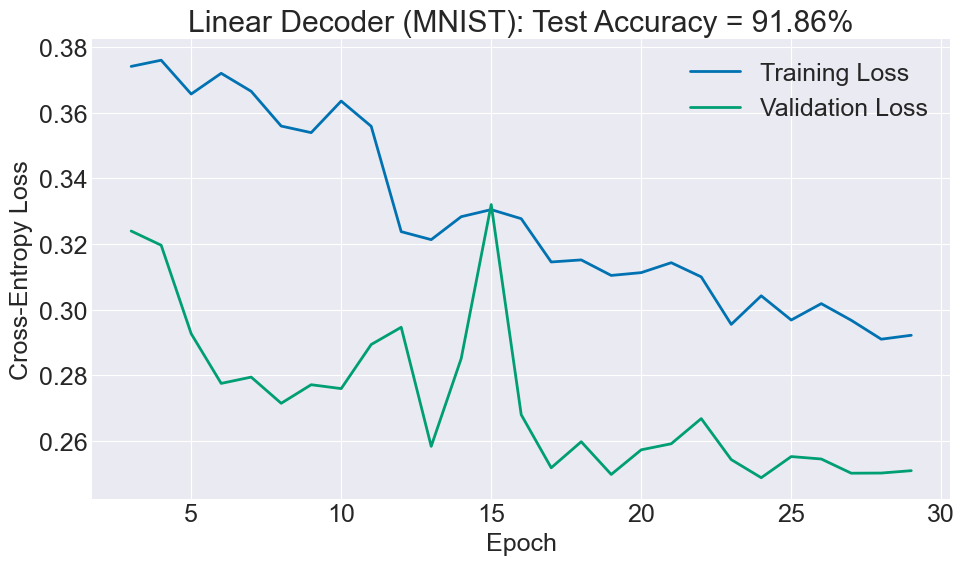

In [56]:
# Trim the first few epochs to focus on long-term trend
trim = 3
epochs = np.arange(trim, num_epochs_lin_mnist)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, train_loss_lin_mnist[trim:], label='Training Loss', linewidth=2)
ax.plot(epochs, val_loss_lin_mnist[trim:], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title(f'Linear Decoder (MNIST): Test Accuracy = {test_acc_lin_mnist.numpy()*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 9d. Train nonlinear decoder (MNIST)

Repeat what you did for the linear classifier with the nonlinear classifier.

**Note there is one additional step:** Once you get the Hebbian network `net_in` values for the train/validation/test sets, the nonlinear decoding network proposed by Krotov & Hopfield (2019) assumes that the Hebbian network `net_in` values ($h_{ij}$) that serve as the input to the decoder are transformed by the following activation function:

$$x_{ij} = max(h_{ij}, 0)^n$$

where $h_{ij}$ are the Hebbian network `net_in` values. In other words, apply ReLU to the `net_in` values then raise the result to the power `n`. By default, we assume that the hyperparameter $n=4.0$.

You may implement this preprocessing step in the `preprocess_nonlinear` function in `image_datasets.py`. **This additional ReLU step needs to be performed on the `net_in` values representing each of the decoder train, validation, AND test sets!!**

**For full credit** your goal is to have your encoder-decoder system achieve either validation or test accuracy ≥ 97.5%. If this goal is not met, there will be point reductions, depending on how far below your system is from this target.

Here are suggested non-default hyperparameter values:
- patience: 5-9
- learning rate patience: below the regular patience, 3-5
- maximum learning rate decays: 3-4
- loss exponent: the default should do well, though you may be able to do a bit better with an exponent of `5.0`.

**Notes, reminders, and guidelines:**
- Remember that the nonlinear decoder uses the $L^p$ loss! 
- Training should take longer than your linear decoder, but not a lot longer (rough estimate 10-20 minutes).

In [57]:
from image_datasets import preprocess_nonlinear

In [58]:
tf.random.set_seed(0)

n_power = 4

x_train_nl_mnist = preprocess_nonlinear(x_train_hebb, n=n_power)
x_val_nl_mnist   = preprocess_nonlinear(x_val_hebb,   n=n_power)
x_test_nl_mnist  = preprocess_nonlinear(x_test_hebb,  n=n_power)

print(f'Max: {tf.reduce_max(x_train_nl_mnist):.2f}, Mean: {tf.reduce_mean(x_train_nl_mnist):.4f}')

nonlinear_dec_mnist = NonlinearDecoder(
    input_feats_shape=(H,),
    C=C,
    wt_scale=0.1,
    beta=0.0025,   
    loss_exp=2.0   
)
nonlinear_dec_mnist.compile(loss='lp', lr=1e-3)

start_time = time.time()
train_loss_nl_mnist, val_loss_nl_mnist, val_acc_nl_mnist, num_epochs_nl_mnist = nonlinear_dec_mnist.fit(
    x_train_nl_mnist, y_train_mnist_split,
    x_val=x_val_nl_mnist, y_val=y_val_mnist,
    batch_size=256,
    max_epochs=300,
    patience=9,
    lr_patience=3,
    lr_max_decays=5,
    lr_decay_factor=0.5,
    val_every=1,
    print_every=1,
    verbose=True
)
total_time_nl_mnist = time.time() - start_time

test_acc_nl_mnist, test_loss_nl_mnist = nonlinear_dec_mnist.evaluate(x_test_nl_mnist, y_test_mnist)
print(f'\nNonlinear Decoder MNIST Test accuracy: {test_acc_nl_mnist.numpy()*100:.2f}%')
print(f'\nNonlinear Decoder MNIST Validation accuracy: {max(val_acc_nl_mnist)*100:.2f}%')
print(f'Training took: {total_time_nl_mnist:.2f} secs')

Max: 20398.41, Mean: 108.3277
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/299, Training loss 0.264687, Val loss 0.128738, Val acc 0.7820
Epoch 0 took: 4.4 secs
Epoch 1/299, Training loss 0.103504, Val loss 0.080064, Val acc 0.8672
Epoch 1 took: 4.5 secs
Epoch 2/299, Training loss 0.083510, Val loss 0.072503, Val acc 0.8706
Epoch 2 took: 3.9 secs
Epoch 3/299, Training loss 0.077008, Val loss 0.068904, Val acc 0.8741
Epoch 3 took: 3.9 secs
Epoch 4/299, Training loss 0.074203, Val loss 0.066604, Val acc 0.8761
Epoch 4 took: 3.8 secs
Epoch 5/299, Training loss 0.069199, Val loss 0.063819, Val acc 0.8771
Epoch 5 took: 3.8 secs
Epoch 6/299, Training loss 0.068442, Val loss 0.063126, Val acc 0.8789
Epoch 6 took: 3.9 secs
Epoch 7/299, Training loss 0.059623, Val loss 0.030947, Val acc 0.9697
Epoch 7 took: 3.9 secs
Epoch 8/299, Training lo

## Task 6: Train the Competitive Hebbian Network

### 6a. Implement `fit` and train Hebbian network on MNIST

Now is the time to train your Hebbian network on the MNIST training set! Implement the `fit` method and train your Hebbian network with the below hyperparameters. Given the high computational demands, you will want to train your Hebbian network using a GPU.

#### Goal

The goal is to train the Hebbian network so that the netAct values provide an accurate encoding of the MNIST digits. Once the network weights enable this (after the training that you do in this task), next week you will train your neural networks to decode the class label from the Hebbian network netAct values.

#### Live plotting/animation

You will want to set `plot_wts_live`: set to True so that you can visualize the weights dynamically during training every `print_every` epochs! It's really cool to see the learning process in action and it's also a great debugging tool! 

You will want to get this working — it is worth it!

#### Hyperparameters

- Train on the Hebbian network with the full, **centered** 60,000 samples from the training set. Do not create a validation set here. *Since we create the validation set from the training set, training the Hebbian network on the full 60k training set samples will set us up for training the decoder networks with a validation set next week.*
- 500 epochs
- 2000 neurons
- 512 sample mini-batch size
- $k = 6$ neurons that achieve the 6th highest netIn should be inhibited to $-\Delta$
- $\Delta = 0.4$
- `5e-3` learning rate

#### Tips
- If your dynamic weight plots (after epoch 0) look mostly white with some red streaks, try transposing your weight matrix before passing it into `draw_grid_image`!
- Make sure you pass in the correct feature shape into `fit`.
- Your weights should range from (roughly) (-0.5, +0.5) by the end of the training session.
- **I highly recommend saving the network weights if your network once training is done in `fit` (the default). This will save you a lot of time next week when working with the decoder neural networks.** 
- Training is expected to take ~10-15 mins on a GPU.

### 9e: Analyze Nonlinear Decoder performance (MNIST)

Create a well-labeled plot showing the training and validation loss over training epochs. Place the accuracy of the nonlinear classifier on the test set in your plot title.

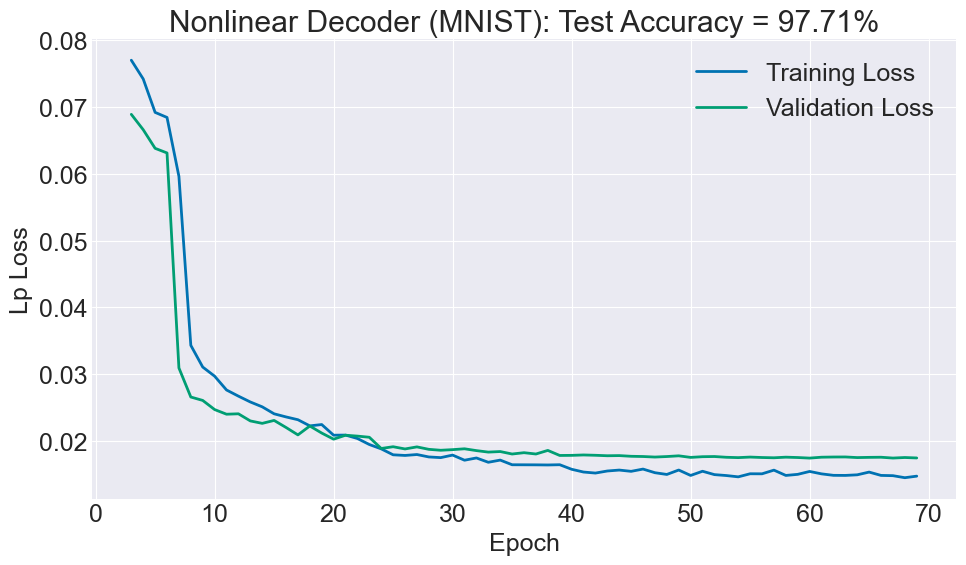

In [59]:
trim = 3
epochs_nl = np.arange(trim, num_epochs_nl_mnist)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_nl, train_loss_nl_mnist[trim:], label='Training Loss', linewidth=2)
ax.plot(epochs_nl, val_loss_nl_mnist[trim:],   label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Lp Loss')
ax.set_title(f'Nonlinear Decoder (MNIST): Test Accuracy = {test_acc_nl_mnist.numpy()*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 9f. Train linear decoder (CIFAR-10)

Train the linear decoder on the `net_in` Hebbian network values obtained to the CIFAR-10 dataset to decode the class labels. Repeat your data loading and training protocols.

**Notes:**
- If you configured your Hebbian network as suggested for CIFAR-10, with 2nd place neurons being inhibited (`k=2`), set `k=2` below when creating and loading your Hebbian network below.
- The same hyperparameters you used to decode MNIST should work fine here too.

In [64]:
# Load CIFAR-10 dataset
x_train_cifar, y_train_cifar, x_test_cifar, y_test_cifar = get_dataset('cifar10', norm_method='center', verbose=True)

# Split into train and validation
x_train_cifar_split, y_train_cifar_split, x_val_cifar, y_val_cifar = train_val_split(x_train_cifar, y_train_cifar)

print(f'Train: {x_train_cifar_split.shape}, Val: {x_val_cifar.shape}, Test: {x_test_cifar.shape}')

# Load pre-trained CIFAR-10 Hebbian network (same hyperparams as Week 2: 2000 neurons, k=2, inhib_value=-0.4)
hebb_cifar = HebbNet(3072, 2000, k=2, inhib_value=-0.4, load_wts=True, saved_wts_path='export/wts_cifar_centered.npy')

# Compute net_in activations for train, val, and test sets
x_train_hebb_cifar = hebb_cifar.net_in(x_train_cifar_split)
x_val_hebb_cifar   = hebb_cifar.net_in(x_val_cifar)
x_test_hebb_cifar  = hebb_cifar.net_in(x_test_cifar)

print(f'Hebbian CIFAR train feats: {x_train_hebb_cifar.shape}')

tf.random.set_seed(0)

H_cifar = x_train_hebb_cifar.shape[1]  # 2000
C_cifar = 10

linear_dec_cifar = LinearDecoder(input_feats_shape=(H_cifar,), C=C_cifar)
linear_dec_cifar.compile(loss='cross_entropy', lr=1e-3)

start_time = time.time()
train_loss_lin_cifar, val_loss_lin_cifar, val_acc_lin_cifar, num_epochs_lin_cifar = linear_dec_cifar.fit(
    x_train_hebb_cifar, y_train_cifar_split,
    x_val=x_val_hebb_cifar, y_val=y_val_cifar,
    batch_size=256,
    max_epochs=200,
    patience=5,
    lr_patience=3,
    lr_max_decays=4,
    lr_decay_factor=0.5,
    val_every=1,
    print_every=1,
    verbose=True
)
total_time_lin_cifar = time.time() - start_time

test_acc_lin_cifar, test_loss_lin_cifar = linear_dec_cifar.evaluate(x_test_hebb_cifar, y_test_cifar)
print(f'\nLinear Decoder CIFAR-10 Test accuracy: {test_acc_lin_cifar.numpy()*100:.2f}%')
print(f'Training took: {total_time_lin_cifar:.2f} secs')

Dataset: cifar10
x_train: (50000, 3072) <dtype: 'float32'>
y_train: (50000,) <dtype: 'uint8'>
x_test:  (10000, 3072) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (45000, 3072), Val: (5000, 3072), Test: (10000, 3072)
Loaded stored wts.
Hebbian CIFAR train feats: (45000, 2000)
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/199, Training loss 3.161296, Val loss 2.622493, Val acc 0.3261
Epoch 0 took: 3.1 secs
Epoch 1/199, Training loss 2.576379, Val loss 2.776481, Val acc 0.3034
Epoch 1 took: 2.1 secs
Epoch 2/199, Training loss 2.449860, Val loss 2.790055, Val acc 0.3083
Epoch 2 took: 2.3 secs
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0005000000237487257>

Make a well-labeled plot showing the training and validation loss over the course of training. Place the test set accuracy in the plot title.

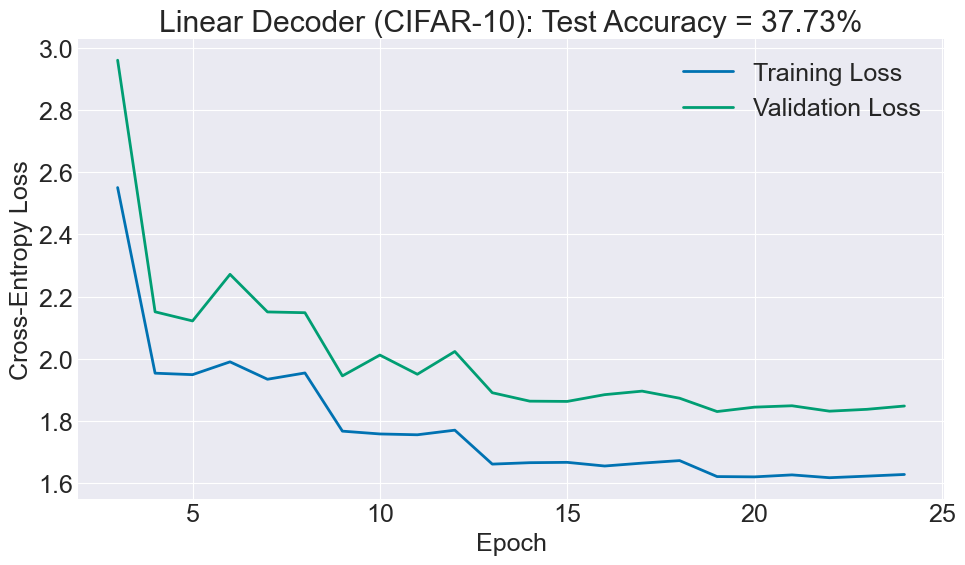

In [61]:
trim = 3
epochs_lin_cifar = np.arange(trim, num_epochs_lin_cifar)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_lin_cifar, train_loss_lin_cifar[trim:], label='Training Loss', linewidth=2)
ax.plot(epochs_lin_cifar, val_loss_lin_cifar[trim:],   label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title(f'Linear Decoder (CIFAR-10): Test Accuracy = {test_acc_lin_cifar.numpy()*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 9g. Train nonlinear decoder (CIFAR-10)

Train the nonlinear decoder on the `net_in` Hebbian network values obtained to the CIFAR-10 dataset to decode the class labels. Repeat your data loading and training protocols.

If you configured your Hebbian network as suggested for CIFAR-10, with 2nd place neurons being inhibited (`k=2`), set `k=2` below when creating and loading your Hebbian network below.

**Suggested non-default hyperparameters:**
- Power `n` to raise Hebbian activations when applying ReLU: `2.0`
- Loss exponent: `4.0`
- patience: 5-9
- learning rate patience: below the regular patience, 3-5
- maximum learning rate decays: 3-4

**For full credit** your goal is to have your encoder-decoder system achieve either validation or test accuracy ≥ 47%. If this goal is not met, there will be point reductions, depending on how far below your system is from this target.

In [ ]:
tf.random.set_seed(0)

x_std_cifar = tf.math.reduce_std(x_train_hebb_cifar)
x_train_hebb_cifar_norm = x_train_hebb_cifar / x_std_cifar
x_val_hebb_cifar_norm   = x_val_hebb_cifar   / x_std_cifar
x_test_hebb_cifar_norm  = x_test_hebb_cifar  / x_std_cifar

n_power_cifar = 2.0
x_train_nl_cifar = preprocess_nonlinear(x_train_hebb_cifar_norm, n=n_power_cifar)
x_val_nl_cifar   = preprocess_nonlinear(x_val_hebb_cifar_norm,   n=n_power_cifar)
x_test_nl_cifar  = preprocess_nonlinear(x_test_hebb_cifar_norm,  n=n_power_cifar)

print(f'Nonlinear preprocessed CIFAR train shape: {x_train_nl_cifar.shape}')

H_cifar = x_train_nl_cifar.shape[1]  # 2000
C_cifar = 10

nonlinear_dec_cifar = NonlinearDecoder(
    input_feats_shape=(H_cifar,),
    C=C_cifar,
    wt_scale=0.1,
    beta=0.0025,
    loss_exp=4.0
)
nonlinear_dec_cifar.compile(loss='lp', lr=1e-3)

start_time = time.time()
train_loss_nl_cifar, val_loss_nl_cifar, val_acc_nl_cifar, num_epochs_nl_cifar = nonlinear_dec_cifar.fit(
    x_train_nl_cifar, y_train_cifar_split,
    x_val=x_val_nl_cifar, y_val=y_val_cifar,
    batch_size=256,
    max_epochs=200,
    patience=9,
    lr_patience=5,
    lr_max_decays=4,
    lr_decay_factor=0.5,
    val_every=1,
    print_every=1,
    verbose=True
)
total_time_nl_cifar = time.time() - start_time

test_acc_nl_cifar, test_loss_nl_cifar = nonlinear_dec_cifar.evaluate(x_test_nl_cifar, y_test_cifar)
print(f'\nNonlinear Decoder CIFAR-10 Test accuracy: {test_acc_nl_cifar.numpy()*100:.2f}%')
print(f'Training took: {total_time_nl_cifar:.2f} secs')

Nonlinear preprocessed CIFAR train shape: (45000, 2000)
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/199, Training loss 1.404646, Val loss 1.193393, Val acc 0.2603
Epoch 0 took: 4.2 secs
Epoch 1/199, Training loss 1.053035, Val loss 1.002851, Val acc 0.3250
Epoch 1 took: 3.8 secs
Epoch 2/199, Training loss 0.890192, Val loss 0.891029, Val acc 0.3507
Epoch 2 took: 2.4 secs
Epoch 3/199, Training loss 0.786261, Val loss 0.819621, Val acc 0.3673
Epoch 3 took: 2.7 secs
Epoch 4/199, Training loss 0.710131, Val loss 0.755545, Val acc 0.3837
Epoch 4 took: 3.6 secs
Epoch 5/199, Training loss 0.650831, Val loss 0.712697, Val acc 0.3920
Epoch 5 took: 4.1 secs
Epoch 6/199, Training loss 0.603691, Val loss 0.674753, Val acc 0.4031
Epoch 6 took: 3.9 secs
Epoch 7/199, Training loss 0.558903, Val loss 0.640633, Val acc 0.4120
Epoch 7 took: 4.3 sec

Make a well-labeled plot showing the training and validation loss over the course of training. Place the test set accuracy in the plot title.

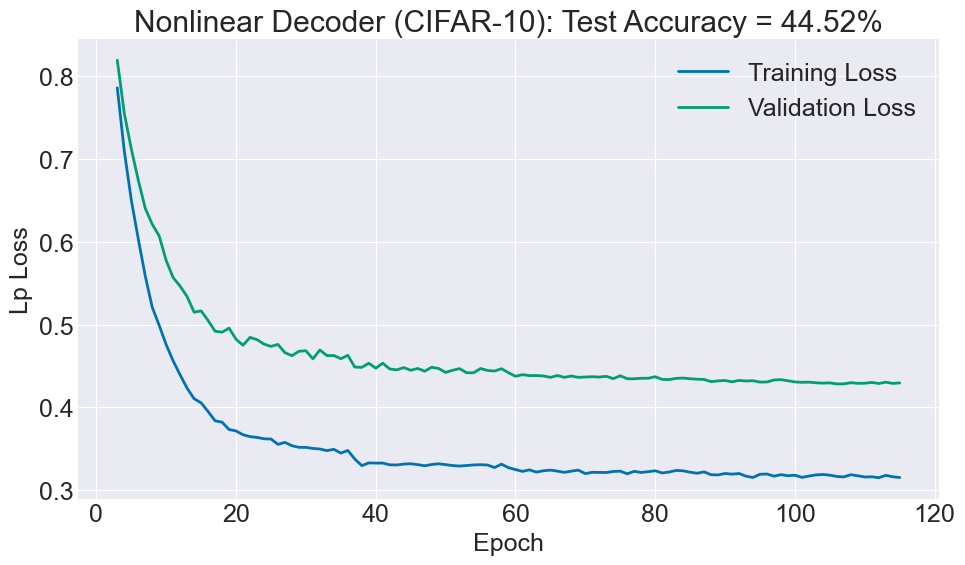

In [63]:
trim = 3
epochs_nl_cifar = np.arange(trim, num_epochs_nl_cifar)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_nl_cifar, train_loss_nl_cifar[trim:], label='Training Loss', linewidth=2)
ax.plot(epochs_nl_cifar, val_loss_nl_cifar[trim:],   label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Lp Loss')
ax.set_title(f'Nonlinear Decoder (CIFAR-10): Test Accuracy = {test_acc_nl_cifar.numpy()*100:.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 9h. Questions

**Question 14:** Describe one specific case (*linear or nonlinear decoder paired with MNIST or CIFAR-10*)where the learning rate decay made a substantial difference in the validation accuracy that your encoder-decoder system achieved. What results would you have achieved with and without this technique? *You should be able to answer this question based on your training print outs; you do NOT need to retrain your networks to answer this question.*

**Answer 14:** The clearest example is the linear decoder on CIFAR-10. Without any lr decay, the model was stuck in a plateau at ~31–35% val accuracy through epochs 0–2, with val loss oscillating around 2.64–2.87 and no meaningful improvement. The first decay (0.001 → 0.0005) triggered after epoch 2, and the effect was immediate: val accuracy jumped from 30.3% to 35.42% by epoch 5 — a gain of over 5 percentage points in just two epochs.
Each subsequent decay produced a similar step-change: the second decay (→ 0.00025) after epoch 7 pushed val accuracy from ~34% up to 37.03% by epoch 14, and the third and fourth decays continued driving improvements to a peak of 37.80% at epoch 24.
Without lr decay, the model would have triggered early stopping within the first ~5 epochs, converging around 30–31% val accuracy — the level it was stuck at before the first decay fired. The lr decay schedule was essential here because CIFAR-10 features are noisier and harder to separate than MNIST, so the optimizer needed progressively smaller step sizes to find and exploit the finer structure in the loss landscape. The final test accuracy of 37.69% would not have been achievable without it.

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.** 
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric). 
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 1. Compare encoder-decoder model to end-to-end training

Compare your results from this project to other end-to-end artificial neural networks trained directly on MNIST or CIFAR-10 (e.g. MLPs, CNNs). I would suggest keeping hyperparameters constant for a fair comparison. There is a lot to explore here! Here are a few questions to examine:
- Are there differences in how rapidly the systems learn their inputs (e.g. number of training epochs needed to achieve "good" accuracy on the validation set)?
- What test accuracy is achievable?
- How does the total training time compare?

In your analysis, account for the complexity/number of parameters in each system.

#### 2. Hyperparameter explorations

Explore how the hyperparameters affect classification accuracy. Can you improve upon the results from the base project?

- Remember, the encoder has numerous hyperparameters to experiment with. For example, remember that you can also control the dimension of the "embedding" performed by the Hebbian network (i.e. number of neurons in the net), the amount of inhibition, etc. 
- Use a grid or random search for encoder and/decoder networks to optimize performance.

#### 3. Use your CS 343 Softmax network as the linear decoder

This will require a few updates to support the Adam optimizer (that you implemented in the CS 343 CNN project) and validation sets.

Copy `softmax_layer.py` from your CS343 MLP project to your working directory. Also copy `optimizer.py` from your CS343 CNN project.

Make the following changes to `fit()` in `softmax_layer.py`:
1. Switch your optimizer from SGD to Adam. This will involve creating two `Adam` objects: one for the weights, one for the bias. Also, be sure to set the Adam learning rate based on the value passed into `fit()`.
2. Add support in `fit()` for a validation set by adding the keyword arguments: `x_val=None, y_val=None`. If `verbose > 0` print out the accuracy and loss over the entire validation set. 
3. If `verbose > 0` convert your print outs to happen in terms of epochs rather than iterations (e.g. every epoch, not every 100 iterations). Add a keyword argument `val_freq=50` to specify how often (in epochs) to check and print out the validation accuracy and loss. Be sure to always print out the validation accuracy and loss on the first and last epoch regardless of the `val_freq` value.
4. Have `fit()` return both the train and validation loss as Python lists or ndarrays. In cases when you do not pass in a validation set, the returned validation loss list may be `None` and that's ok.

The network should train similarily to your Tensorflow version. Compare/analyze runtime performance.

#### 4. Encode an image dataset of your choice with the Hebbian network

For example, Fashion MNIST, STL-10 or CIFAR-100. If your images contain color, I suggest either converting to grayscale or flattening the color channels when constructing your feature vectors (e.g. `(32, 32, 3)` color image made into a `(3072,)` vector).

Some areas to explore:
- Visualize the weights. Analyze how hyperparameters affect the structure.
- Compare decoding accuracy


#### 5. Learning rate decay alternatives

Krotov & Hopfield (2019) not only used step decays, similar to the approach taken in the project, but in some cases also linear decays, where the linear rate decayed by a fixed amount on every epoch. There are many other ways to the decay learning rate. Implement the linear decay or your own variant (for either encoder and/or decoder network) and explore whether it improves decoding performance.

#### 6. Early stopping alternatives

There are many other ways to implement early stopping. For example, you could abort training when the current val loss exceeds the recent moving average. Implement this or your own variant (for either encoder and/or decoder network) and explore whether it improves decoding performance.

#### 7. Confusion matrix and error analysis of MNIST classification

For one or both classifier, make a confusion matrix of the digit classifications. Use your confusion matrix to gain insight into misclassifications. Run follow-up analyses/training sessions to explore patterns in more depth. For example, if two classes are frequently misclassified, how neurons in the Hebbian network develop receptive fields that resemble each? Are the weights resembling the two classes strongly correlated (and how?)? To what degree are inhibitory weights learned for these neurons? What happens if you train the Hebbian network on only samples belonging to the two classes — do classes of either class become less/more confusable? And so forth...

<!-- ### 8. Implement the Generalized Hebbian Algorithm (GHA) and compare to PCA

The GHA provides an incremental version of PCA — compute PCA one sample at a time over a number of training epochs. This approach can be helpful when you want to run PCA on a large dataset, but the dataset is too large to fit in your computer's memory (e.g. perhaps STL-10 at full 96x96 resolution). 

Implement GHA then show for a large dataset (e.g. STL-10) that GHA computes the PCA representation, whereas regular PCA (e.g. from CS251/2) fails. Plot what the image samples look like over training epochs when projected to PCA space and then back to the original data space (i.e. filtered by the learned principle components / network weights). If this sounds interesting, please see me for guidance. -->

#### 8. Experiment with different decoder architectures

Create one or more different nonlinear decoders in TensorFlow (e.g. MLP, CNN). Compare performance/accuracy with the nonlinear one in the project.